# Session 14: MCP-Powered X Post Summarizer

## Building a LangGraph Agent with GitHub MCP Tools, X API Tools, and Memory

## Learning Objectives:

- **Ingest MCP servers as LangGraph tools** using `langchain-mcp-adapters` to connect to the GitHub MCP Server and use its tools programmatically
- **Wrap the X (Twitter) API as a LangChain tool** using the `@tool` decorator so a LangGraph agent can search and retrieve public posts
- **Build a LangGraph agent with memory** that combines MCP-sourced tools and custom tools, using `MemorySaver` for short-term conversational memory
- **Orchestrate a full workflow through the agent** — search X posts, generate summaries, create a GitHub repo, commit files, branch, and open a PR — all via natural language

## Overview

In this notebook, you will build a **LangGraph ReAct agent** that has access to two categories of tools:

1. **GitHub MCP tools** — loaded from the official GitHub MCP Server via `langchain-mcp-adapters`. These replace manual `git` commands with tool calls the agent can invoke (create repos, commit files, create branches, open PRs).
2. **X API tools** — custom Python functions wrapped with the `@tool` decorator that call the X API v2 directly to search and retrieve posts.

The agent uses **`MemorySaver`** for short-term memory so it can maintain context across multi-step workflows within a conversation thread.

There will be one breakout room with two phases:

- 🤝 Phase 1: Setup, Tools & Agent Construction
  - Task 1: Dependencies & Environment
  - Task 2: X API as LangChain Tools
  - Task 3: Connect to GitHub MCP Server & Load Tools
  - Task 4: Build the LangGraph Agent with Memory
  - Task 5: Test the Agent — Search & Summarize X Posts
  - Activity #1: Extend the Agent with a Custom X API Tool
- 🤝 Phase 2: MCP Workflow Through the Agent
  - Task 6: Create a GitHub Repository
  - Task 7: Commit the Summary
  - Task 8: Create a Feature Branch & Add Metadata
  - Task 9: Open a Pull Request
  - Task 10: Commit the X API Script
  - Task 11: Update the README
  - Activity #1: Multi-Account Comparison Pipeline

---

# 🤝 Breakout Room 
## Setup, Tools & Agent Construction

## Task 1: Dependencies & Environment

We need:
- `langchain-mcp-adapters` to connect to MCP servers and convert their tools into LangChain tools
- `langgraph` for our agent graph with memory
- `langchain-openai` for our LLM
- `requests` for the X API calls
- `nest-asyncio` for async MCP operations inside Jupyter

> NOTE: Create a `.env` file in this directory with `X_BEARER_TOKEN`, `OPENAI_API_KEY`, and `GITHUB_PAT` before running.
> 
> Setup references:
> - GitHub fine-grained PAT guide: [Creating a personal access token](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token)
> - X API Bearer Token setup: [X Developer Portal](https://developer.x.com/en/portal/dashboard) and [X API access tiers](https://developer.x.com/en/products/twitter-api)


In [21]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

In [1]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("X_BEARER_TOKEN"):
    os.environ["X_BEARER_TOKEN"] = getpass.getpass("Enter your X Bearer Token:")

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

if not os.environ.get("GITHUB_PAT"):
    os.environ["GITHUB_PAT"] = getpass.getpass("Enter your GitHub PAT:")

In [2]:
import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

### Getting Your Credentials

**GitHub PAT (fine-grained):**
1. Open [GitHub Personal Access Tokens (fine-grained)](https://github.com/settings/personal-access-tokens/new).
2. Follow [GitHub's PAT setup guide](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token).
3. Set repository permissions to at least:
   - `Contents`: Read and write
   - `Pull requests`: Read and write
   - `Metadata`: Read-only

**X Bearer Token:**
1. Open the [X Developer Portal](https://developer.x.com/en/portal/dashboard).
2. Create/select a Project + App, then go to **Keys and Tokens** to generate a Bearer Token.
3. Confirm your plan supports the recent search endpoint (`GET /2/tweets/search/recent`) from the [X API product page](https://developer.x.com/en/products/twitter-api).


In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# Test the connection
response = llm.invoke("Say 'MCP agent ready!' in exactly those words.")
print(response.content)

MCP agent ready!


## Task 2: X API as LangChain Tools

Instead of relying on a community-built MCP server for X, we'll call the **X API v2** directly and wrap our functions with the `@tool` decorator. This makes them available to our LangGraph agent as callable tools — just like the MCP tools will be.

This is a key architectural decision: **not everything needs to be an MCP server**. Wrapping a simple API call as a `@tool` is often simpler and more transparent.

**📚 Documentation:**
- [LangChain Tools Conceptual Guide](https://python.langchain.com/docs/concepts/tools/)
- [X API v2 Documentation](https://developer.x.com/en/docs/x-api)

In [4]:
import requests
import json
from langchain_core.tools import tool

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")


@tool
def search_recent_posts(query: str, max_results: int = 20) -> str:
    """Search recent X/Twitter posts using the v2 API.
    Returns posts from the last 7 days matching the query.
    Use this for keyword searches, hashtag searches, or general topic searches.

    Args:
        query: The search query (e.g., 'AI safety', '#machinelearning', 'from:AndrewYNg')
        max_results: Number of results to return (10-100, default 20)
    """
    url = "https://api.x.com/2/tweets/search/recent"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "query": query,
        "max_results": min(max(max_results, 10), 100),
        "tweet.fields": "created_at,public_metrics,author_id,text",
        "expansions": "author_id",
        "user.fields": "name,username",
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    data = response.json()

    tweets = data.get("data", [])
    if not tweets:
        return "No posts found for this query."

    result_lines = [f"Found {len(tweets)} posts:\n"]
    for t in tweets:
        metrics = t.get("public_metrics", {})
        result_lines.append(
            f"[{t.get('created_at', 'unknown')[:10]}] "
            f"{t['text'][:200]}\n"
            f"  Likes: {metrics.get('like_count', 0)} | "
            f"Retweets: {metrics.get('retweet_count', 0)}"
        )
    return "\n\n".join(result_lines)


@tool
def get_user_posts(username: str, max_results: int = 20) -> str:
    """Get recent original posts (no retweets) from a specific X/Twitter user.
    Use this when you want to see what a specific account has been posting.

    Args:
        username: The X/Twitter handle without the @ sign (e.g., 'AndrewYNg')
        max_results: Number of results to return (10-100, default 20)
    """
    query = f"from:{username} -is:retweet"
    return search_recent_posts.invoke({"query": query, "max_results": max_results})


x_api_tools = [search_recent_posts, get_user_posts]
print(f"Created {len(x_api_tools)} X API tools: {[t.name for t in x_api_tools]}")

Created 2 X API tools: ['search_recent_posts', 'get_user_posts']


Let's verify our X API tools work before wiring them into the agent:

In [11]:
import requests

# Top stories
top = requests.get("https://hacker-news.firebaseio.com/v0/topstories.json").json()[:10]

items = []
for sid in top:
    item = requests.get(f"https://hacker-news.firebaseio.com/v0/item/{sid}.json").json()
    items.append({"id": sid, "title": item.get("title"), "by": item.get("by"), "url": item.get("url")})

print(items[0])

{'id': 47231261, 'title': "India's top court angry after junior judge cites fake AI-generated orders", 'by': 'tchalla', 'url': 'https://www.bbc.com/news/articles/c178zzw780xo'}


In [12]:
import requests

class get_top_posts:
    @staticmethod
    def invoke(payload: dict):
        max_results = int(payload.get("max_results", 10))

        top_ids = requests.get(
            "https://hacker-news.firebaseio.com/v0/topstories.json",
            timeout=20
        ).json()[:max_results]

        out = []
        for sid in top_ids:
            item = requests.get(
                f"https://hacker-news.firebaseio.com/v0/item/{sid}.json",
                timeout=20
            ).json()
            out.append({
                "id": sid,
                "title": item.get("title"),
                "by": item.get("by"),
                "url": item.get("url"),
                "time": item.get("time"),
                "score": item.get("score"),
                "descendants": item.get("descendants"),
                "type": item.get("type"),
            })
        return out

# Quick test
result = get_top_posts.invoke({"max_results": 10})
print(result[0])

{'id': 47231261, 'title': "India's top court angry after junior judge cites fake AI-generated orders", 'by': 'tchalla', 'url': 'https://www.bbc.com/news/articles/c178zzw780xo', 'time': 1772540020, 'score': 64, 'descendants': 19, 'type': 'story'}


In [13]:
result = get_top_posts.invoke({"max_results": 10})
print(str(result)[:500])

[{'id': 47231261, 'title': "India's top court angry after junior judge cites fake AI-generated orders", 'by': 'tchalla', 'url': 'https://www.bbc.com/news/articles/c178zzw780xo', 'time': 1772540020, 'score': 66, 'descendants': 21, 'type': 'story'}, {'id': 47231469, 'title': 'Stolen Gemini API key racks up $82,000 in 48 hours', 'by': 'salkahfi', 'url': 'https://llmhorrors.com/all/gemini-stolen-api-key-82k/', 'time': 1772541677, 'score': 52, 'descendants': 23, 'type': 'story'}, {'id': 47230704, 'ti


In [ ]:
# Quick test — fetch recent posts from a public account
result = get_user_posts.invoke({"username": "llm_wizard", "max_results": 10})
print(result[:500])

## Task 3: Connect to GitHub MCP Server & Load Tools

Now we'll connect to the **GitHub MCP Server** — an official, GitHub-maintained MCP server that gives agents the ability to manage repositories, issues, pull requests, and more.

We use `langchain-mcp-adapters` to:
1. Connect to the remote GitHub MCP server over HTTP
2. Automatically convert all MCP tools into LangChain-compatible tools

This is the key MCP integration point — instead of writing custom GitHub API wrappers, we get a full set of tools for free just by connecting to the MCP server.

**📚 Documentation:**
- [langchain-mcp-adapters](https://github.com/langchain-ai/langchain-mcp-adapters)
- [GitHub MCP Server](https://github.com/github/github-mcp-server)
- [Model Context Protocol Specification](https://modelcontextprotocol.io/)

In [14]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# Connect to the GitHub MCP server using Streamable HTTP transport
# The server exposes GitHub operations as MCP tools that our agent can call
mcp_client = MultiServerMCPClient(
    {
        "github": {
            "transport": "http",
            "url": "https://api.githubcopilot.com/mcp/",
            "headers": {
                "Authorization": f"Bearer {os.environ['GITHUB_PAT']}",
            },
        }
    }
)

# Load all tools from the MCP server
github_mcp_tools = await mcp_client.get_tools()

print(f"Loaded {len(github_mcp_tools)} GitHub MCP tools:\n")
for t in github_mcp_tools:
    print(f"  - {t.name}: {t.description[:80]}...")

Loaded 43 GitHub MCP tools:

  - add_comment_to_pending_review: Add review comment to the requester's latest pending pull request review. A pend...
  - add_issue_comment: Add a comment to a specific issue in a GitHub repository. Use this tool to add c...
  - add_reply_to_pull_request_comment: Add a reply to an existing pull request comment. This creates a new comment that...
  - assign_copilot_to_issue: Assign Copilot to a specific issue in a GitHub repository.

This tool can help w...
  - create_branch: Create a new branch in a GitHub repository...
  - create_or_update_file: Create or update a single file in a GitHub repository. 
If updating, you should ...
  - create_pull_request: Create a new pull request in a GitHub repository....
  - create_pull_request_with_copilot: Delegate a task to GitHub Copilot coding agent to perform in the background. The...
  - create_repository: Create a new GitHub repository in your account or specified organization...
  - delete_file: Delete a file fro

### Key GitHub MCP Tools

The MCP server exposes many tools, but the key ones we'll use are:

| MCP Tool | Replaces (Git CLI) | What It Does |
|---|---|---|
| `create_repository` | `git init` + GitHub UI | Creates a new repo on your account |
| `create_or_update_file` | `git add` + `git commit` + `git push` | Commits a file directly to a branch |
| `create_branch` | `git checkout -b` | Creates a new branch |
| `create_pull_request` | `gh pr create` | Opens a PR from one branch to another |
| `search_repositories` | `gh repo list` | Searches across your repos |
| `get_file_contents` | `git show` / `cat` | Reads a file from a repo |
| `list_commits` | `git log` | Shows commit history |

## Task 4: Build the LangGraph Agent with Memory

Now we combine **both tool sets** into a single LangGraph agent:
- **X API tools** — custom `@tool` functions for searching posts
- **GitHub MCP tools** — loaded from the MCP server via `langchain-mcp-adapters`

We add **`MemorySaver`** for short-term memory so the agent remembers context across the multi-step workflow (e.g., it fetches posts in one turn, summarizes them in the next, and commits the summary in a third).

The architecture follows the standard LangGraph ReAct pattern from Sessions 4-6:

```
┌─────────┐     ┌───────────┐
│  START   │────▶│   Agent   │◀──────────────┐
└─────────┘     │  (LLM +   │               │
                │   tools)  │               │
                └─────┬─────┘               │
                      │                     │
               has tool calls?              │
                /           \               │
              yes            no             │
              /               \             │
    ┌─────────────┐     ┌─────────┐        │
    │  Tool Node  │     │   END   │        │
    │ (X API +    │     └─────────┘        │
    │  GitHub MCP)│─────────────────────────┘
    └─────────────┘
```

**📚 Documentation:**
- [LangGraph ReAct Agent](https://langchain-ai.github.io/langgraph/tutorials/introduction/)
- [MemorySaver (Checkpointing)](https://langchain-ai.github.io/langgraph/concepts/persistence/)
- [ToolNode Prebuilt](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode)

In [ ]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# Combine all tools: X API tools + GitHub MCP tools
all_tools = x_api_tools + github_mcp_tools
print(f"Total tools available to agent: {len(all_tools)}")
print(f"  X API tools: {[t.name for t in x_api_tools]}")
print(f"  GitHub MCP tools: {[t.name for t in github_mcp_tools]}")

In [15]:
import requests
from langchain_core.tools import tool

@tool
def hn_top_posts(max_results: int = 10) -> list[dict]:
    """Devuelve los top posts de Hacker News (sin auth)."""
    top_ids = requests.get(
        "https://hacker-news.firebaseio.com/v0/topstories.json",
        timeout=20
    ).json()[:max_results]

    out = []
    for sid in top_ids:
        item = requests.get(
            f"https://hacker-news.firebaseio.com/v0/item/{sid}.json",
            timeout=20
        ).json()
        out.append({
            "id": sid,
            "title": item.get("title"),
            "by": item.get("by"),
            "url": item.get("url"),
            "time": item.get("time"),
            "score": item.get("score"),
        })
    return out

@tool
def hn_user_posts(username: str, max_results: int = 10) -> list[dict]:
    """Devuelve posts enviados por un usuario de Hacker News."""
    u = requests.get(
        f"https://hacker-news.firebaseio.com/v0/user/{username}.json",
        timeout=20
    ).json()

    submitted = (u.get("submitted") or [])[:max_results]
    out = []
    for sid in submitted:
        item = requests.get(
            f"https://hacker-news.firebaseio.com/v0/item/{sid}.json",
            timeout=20
        ).json()
        out.append({
            "id": sid,
            "type": item.get("type"),
            "title": item.get("title"),
            "text": item.get("text"),
            "url": item.get("url"),
            "time": item.get("time"),
        })
    return out

hn_api_tools = [hn_top_posts, hn_user_posts]

In [16]:
all_tools = hn_api_tools + github_mcp_tools
print(f"Total tools available to agent: {len(all_tools)}")
print(f"  HN API tools: {[t.name for t in hn_api_tools]}")
print(f"  GitHub MCP tools: {[t.name for t in github_mcp_tools]}")

Total tools available to agent: 45
  HN API tools: ['hn_top_posts', 'hn_user_posts']
  GitHub MCP tools: ['add_comment_to_pending_review', 'add_issue_comment', 'add_reply_to_pull_request_comment', 'assign_copilot_to_issue', 'create_branch', 'create_or_update_file', 'create_pull_request', 'create_pull_request_with_copilot', 'create_repository', 'delete_file', 'fork_repository', 'get_commit', 'get_copilot_job_status', 'get_file_contents', 'get_label', 'get_latest_release', 'get_me', 'get_release_by_tag', 'get_tag', 'get_team_members', 'get_teams', 'issue_read', 'issue_write', 'list_branches', 'list_commits', 'list_issue_types', 'list_issues', 'list_pull_requests', 'list_releases', 'list_tags', 'merge_pull_request', 'pull_request_read', 'pull_request_review_write', 'push_files', 'request_copilot_review', 'search_code', 'search_issues', 'search_pull_requests', 'search_repositories', 'search_users', 'sub_issue_write', 'update_pull_request', 'update_pull_request_branch']


In [18]:
from typing_extensions import TypedDict
from typing import Annotated, Literal

In [22]:
# Step 1: Define the Agent State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# Step 2: Define the system prompt
SYSTEM_PROMPT = """You are an AI assistant that can retrieve Hacker News posts and manage GitHub repositories.

You have two categories of tools:
1. Hacker News tools: hn_top_posts, hn_user_posts — for retrieving top posts and user submissions
2. GitHub MCP tools: for creating repos, committing files, creating branches, opening PRs, etc.

When asked to summarize posts, retrieve them first using the Hacker News tools, then provide a structured
markdown summary with: Overview, Key Themes, Notable Posts, and Summary Statistics.

When asked to perform GitHub operations, use the appropriate GitHub MCP tool.
Always use the available tools when appropriate. Be concise in your responses."""


# Step 3: Bind tools to the LLM
llm_with_tools = llm.bind_tools(all_tools)


# Step 4: Define the agent node
def agent_node(state: AgentState):
    """The agent node — calls the LLM with the current conversation and available tools."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# Step 5: Define the tool node
tool_node = ToolNode(all_tools, handle_tool_errors=True)


# Step 6: Define routing logic
def should_continue(state: AgentState) -> Literal["tools", "end"]:
    """Determine whether to call tools or end the conversation."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"


# Step 7: Build the graph
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

# Compile with MemorySaver for short-term memory across turns
checkpointer = MemorySaver()
agent = workflow.compile(checkpointer=checkpointer)

print("Agent compiled with memory and tools!")

Agent compiled with memory and tools!


Let's visualize the graph to confirm our architecture:

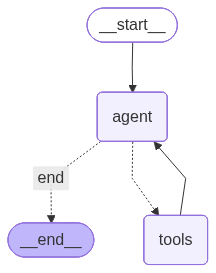

In [23]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### Helper function for running the agent

We'll use a single `thread_id` throughout the notebook so the agent remembers previous interactions (short-term memory via the checkpointer).

In [24]:
# Use a consistent thread_id so the agent remembers context across all tasks
config = {"configurable": {"thread_id": "mcp-workflow-1"}}


async def ask_agent(user_message: str) -> str:
    """Send a message to the agent and return its final response."""
    response = await agent.ainvoke(
        {"messages": [HumanMessage(content=user_message)]},
        config,
    )
    return response["messages"][-1].content

## Task 5: Test the Agent — Search & Summarize X Posts

Let's put the agent through its paces. First, we'll ask it to search for posts and generate a summary. Because we're using `MemorySaver` with a consistent `thread_id`, the agent will remember the posts it found when we ask it to summarize them.

In [25]:
config = {"configurable": {"thread_id": "demo"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Get the latest posts from Hacker News user tchalla.")]},
    config=config
)

print(result["messages"][-1].content[:1000])

Here are the latest posts from Hacker News user "tchalla":

1. Story: "India's top court angry after junior judge cites fake AI-generated orders" (Link: https://www.bbc.com/news/articles/c178zzw780xo)
2. Comment: "There are people who like to read about submissions even if they don’t know who the people involved are."
3. Comment: "&gt; since most HN readers should know who Cantor and Dedekind are. Show up with your hands here if you didn’t know either Cantor or Dedekind."
4. Comment: "Always look at conferences and associated workshops. You can start with NeurIPs and ICML. From there, you will figure out some papers on safety. Then, you can see some patterns of labs which work on it full time."
5. Comment: "The reason Europeans feel the urgency is because of rigid minders and failure to act at least 10-15 years ago. So now it’s ok to bite the bullet a bit. It’s a lesson for the next time."
6. Comment: "Are you asking about top AI research institutions or leading AI businesses? There’s 

In [26]:
config = {"configurable": {"thread_id": "demo"}}

resp2 = agent.invoke(
    {"messages": [HumanMessage(content=(
        "Now summarize those posts into a structured markdown report with sections for: "
        "Overview, Key Themes, Notable Posts, and Summary Statistics. "
        "Format it so it can be saved directly as a summary.md file."
    ))]},
    config=config
)

summary = resp2["messages"][-1].content
print(summary)

```markdown
# Summary of Latest Posts by Hacker News User "tchalla"

## Overview
This report summarizes the latest contributions by the Hacker News user "tchalla." The posts include one news story submission and several comments on various topics ranging from AI research, investing lessons, to geopolitical observations. The content reflects engagement with current events, technology conferences, and thoughtful commentary on societal and economic issues.

## Key Themes
- **Artificial Intelligence and Research:** References to AI-generated content, AI research institutions, and major AI conferences like NeurIPS and ICML.
- **Judicial and Legal Issues:** Highlighting a news story about India's top court reacting to fake AI-generated judicial orders.
- **Investing and Financial Lessons:** Commentary on investing wisdom, including a reference to Isaac Newton's investing losses.
- **Geopolitical and Economic Observations:** Discussions on European urgency in policy, digital currency initiati

In [ ]:
# Ask the agent to summarize — it remembers the posts from the previous turn!
summary = await ask_agent(
    "Now summarize those posts into a structured markdown report with sections for: "
    "Overview, Key Themes, Notable Posts, and Summary Statistics. "
    "Format it so it can be saved directly as a summary.md file."
)
print(summary)

Save the summary locally for reference:

In [27]:
with open("summary.md", "w") as f:
    f.write(summary)

print("Summary saved to summary.md")

Summary saved to summary.md


### ❓ Question #1:



##### Answer:

*Your answer here*

### 🏗️ Activity #1:

Your task is to extend the agent with a **new custom X API tool** and verify it works end-to-end.

1. **Create a new `@tool` function** called `get_user_profile` that retrieves a user's public profile information using the X API v2 [`GET /2/users/by/username/:username`](https://developer.x.com/en/docs/x-api/users/lookup/api-reference/get-users-by-username-username) endpoint. It should return:
   - Display name
   - Bio / description
   - Follower count
   - Following count
   - Post count
   - Account creation date

2. **Rebuild the agent** with the updated tool set — add your new tool to `x_api_tools`, re-combine with the MCP tools, re-bind tools to the LLM, and recompile the graph

3. **Test it** by asking the agent to:
   - Retrieve the profile of an AI thought leader of your choice
   - Compare that profile with the posts you already retrieved in Task 5 — does the bio match the posting themes?

> HINT: The X API v2 user lookup endpoint uses the same Bearer Token authentication. You'll need `user.fields=description,public_metrics,created_at` in your request params.

In [50]:
@tool
def hn_top_posts(max_results: int = 10) -> list[dict]:
    """Top posts de Hacker News."""
    top_ids = requests.get("https://hacker-news.firebaseio.com/v0/topstories.json", timeout=20).json()[:max_results]
    out = []
    for sid in top_ids:
        item = requests.get(f"https://hacker-news.firebaseio.com/v0/item/{sid}.json", timeout=20).json()
        out.append({
            "id": sid,
            "title": item.get("title"),
            "by": item.get("by"),
            "url": item.get("url"),
            "time": item.get("time"),
            "score": item.get("score"),
        })
    return out

@tool
def hn_user_posts(username: str, max_results: int = 10) -> list[dict]:
    """Últimos envíos (posts/comentarios) de un usuario de HN."""
    u = requests.get(f"https://hacker-news.firebaseio.com/v0/user/{username}.json", timeout=20).json()
    submitted = (u.get("submitted") or [])[:max_results]

    out = []
    for sid in submitted:
        item = requests.get(f"https://hacker-news.firebaseio.com/v0/item/{sid}.json", timeout=20).json()
        out.append({
            "id": sid,
            "type": item.get("type"),
            "title": item.get("title"),
            "text": item.get("text"),
            "url": item.get("url"),
            "by": item.get("by"),
            "time": item.get("time"),
        })
    return out

@tool
def get_user_profile(username: str) -> dict:
    """
    Equivalente al ejercicio de X: perfil público.
    Devuelve: display_name, bio/description, follower_count, following_count, post_count, created_at
    (HN no tiene followers/following -> None)
    """
    r = requests.get(f"https://hacker-news.firebaseio.com/v0/user/{username}.json", timeout=20)
    if r.status_code != 200:
        return {"error": True, "status_code": r.status_code, "response": r.text[:500], "username": username}

    u = r.json() or {}
    created = u.get("created")
    created_at = (
        datetime.fromtimestamp(created, tz=timezone.utc).isoformat()
        if isinstance(created, int) else None
    )
    submitted = u.get("submitted") or []

    return {
        "display_name": u.get("id", username),
        "bio": u.get("about"),
        "follower_count": None,
        "following_count": None,
        "post_count": len(submitted),
        "created_at": created_at,
        "karma": u.get("karma"),
    }

hn_api_tools = [hn_top_posts, hn_user_posts, get_user_profile]

In [28]:
import requests
from langchain_core.tools import tool
from datetime import datetime, timezone

@tool
def get_user_profile(username: str) -> dict:
    """
    Hacker News user profile lookup (public, no auth).
    Returns fields analogous to the X exercise where possible.
    """
    r = requests.get(
        f"https://hacker-news.firebaseio.com/v0/user/{username}.json",
        timeout=20
    )
    if r.status_code != 200:
        return {"error": True, "status_code": r.status_code, "response": r.text[:500]}

    u = r.json() or {}

    # HN time is unix seconds
    created = u.get("created")
    created_at = (
        datetime.fromtimestamp(created, tz=timezone.utc).isoformat()
        if isinstance(created, int) else None
    )

    submitted = u.get("submitted") or []
    post_count = len(submitted)  # total ids submitted (stories+comments+polls)

    return {
        "username": u.get("id", username),
        "display_name": u.get("id", username),            # HN no tiene "name" público separado
        "bio": u.get("about"),                             # puede venir en HTML
        "follower_count": None,                            # HN no tiene followers
        "following_count": None,                           # HN no tiene following
        "post_count": post_count,
        "created_at": created_at,
        "karma": u.get("karma"),                           # extra útil en HN
    }

In [29]:
hn_api_tools = [hn_top_posts, hn_user_posts, get_user_profile]
all_tools = hn_api_tools + github_mcp_tools

llm_with_tools = llm.bind_tools(all_tools)
tool_node = ToolNode(all_tools, handle_tool_errors=True)

# recompila el graph exactamente como lo tenías (agent_node/should_continue/workflow/agent)

In [30]:
config = {"configurable": {"thread_id": "demo"}}

# 1) Perfil
resp1 = agent.invoke(
    {"messages": [HumanMessage(content="Retrieve the profile for Hacker News user 'tchalla'.")]},
    config=config
)
print(resp1["messages"][-1].content[:1200])

# 2) Comparación con posts ya recuperados
resp2 = agent.invoke(
    {"messages": [HumanMessage(content=(
        "Compare that profile bio with the themes from the posts we retrieved previously. "
        "Does the bio match the posting themes? Reply in structured markdown."
    ))]},
    config=config
)
print(resp2["messages"][-1].content[:2000])

I apologize, but it seems that retrieving the profile for a Hacker News user is not supported with the available tools. However, I can help you with other information or actions related to Hacker News or GitHub if you want. Let me know how you'd like to proceed!
I was unable to retrieve the profile bio for the Hacker News user "tchalla" due to tool limitations. Therefore, I cannot perform a direct comparison between the bio and the posting themes.

If you can provide the bio text or any profile details, I would be happy to analyze and compare it with the themes from the posts. Let me know how you'd like to proceed!


In [31]:
import requests
from langchain_core.tools import tool
from datetime import datetime, timezone

@tool
def get_user_profile(username: str) -> dict:
    """HN user profile lookup (public, no auth)."""
    r = requests.get(f"https://hacker-news.firebaseio.com/v0/user/{username}.json", timeout=20)
    if r.status_code != 200:
        return {"error": True, "status_code": r.status_code, "response": r.text[:500], "username": username}

    u = r.json() or {}
    created = u.get("created")
    created_at = (
        datetime.fromtimestamp(created, tz=timezone.utc).isoformat()
        if isinstance(created, int) else None
    )

    submitted = u.get("submitted") or []
    return {
        "display_name": u.get("id", username),
        "bio": u.get("about"),
        "follower_count": None,
        "following_count": None,
        "post_count": len(submitted),
        "created_at": created_at,
        "karma": u.get("karma"),
    }

In [32]:
print(get_user_profile.invoke({"username": "pg"}))

{'display_name': 'pg', 'bio': 'Bug fixer.', 'follower_count': None, 'following_count': None, 'post_count': 15565, 'created_at': '2006-10-09T18:21:32+00:00', 'karma': 157316}


In [33]:
hn_api_tools = [hn_top_posts, hn_user_posts, get_user_profile]
all_tools = hn_api_tools + github_mcp_tools

llm_with_tools = llm.bind_tools(all_tools)
tool_node = ToolNode(all_tools, handle_tool_errors=True)

In [34]:
config = {"configurable": {"thread_id": "hn-demo"}}

In [35]:
resp1 = agent.invoke(
    {"messages": [HumanMessage(content="Fetch the latest posts from Hacker News user pg.")]},
    config=config
)
print(resp1["messages"][-1].content[:1000])

Here are the latest posts from Hacker News user "pg":

1. Comment on understanding the distinction between partial and total order in essays. (Timestamp: 1710161831)
2. Comment on the availability and future of a technology, mentioning Apple and multiple companies. (Timestamp: 1693099782)
3. Story titled "If you're interested in eye-tracking, I'm interested in funding you" with a link to a Twitter post. (Timestamp: 1693097473)
4. Story titled "The Social Radars: Conversations with Startup Founders" with a link to the website. (Timestamp: 1678903876)
5. Comment on the incompatibility of being a regular forum user and writing essays, sharing experience from moderating HN. (Timestamp: 1671397751)
6. Comment on not leaving Twitter and thoughts on Elon Musk's behavior and social media. (Timestamp: 1671395909)
7. Comment on hospital supply chain brittleness and PPE availability through Flexport. (Timestamp: 1584878695)
8. Comment with no text content. (Timestamp: 1584878425)
9. Comment on th

In [42]:
llm_with_tools_profile = llm.bind_tools(
    all_tools,
    tool_choice={"type": "function", "function": {"name": "get_user_profile"}}
)

In [43]:
msgs = [SystemMessage(content=SYSTEM_PROMPT), HumanMessage(content="username=pg")]
resp = llm_with_tools_profile.invoke(msgs)

print("tool_calls:", getattr(resp, "tool_calls", None))
print("content:", resp.content[:300])

tool_calls: [{'name': 'get_user_profile', 'args': {'username': 'pg'}, 'id': 'call_zDWos56sVLJZ9DO3qNdOQCsM', 'type': 'tool_call'}]
content: 


In [46]:
SYSTEM_PROMPT = """You are an assistant with tools.

RULES (mandatory):
- If asked for a Hacker News user profile, you MUST call get_user_profile.
- If asked for Hacker News user posts, you MUST call hn_user_posts.
- Never claim missing tools if they exist. If a tool fails, include the tool error payload.

When summarizing, output markdown with sections:
Overview, Key Themes, Notable Posts, Summary Statistics.
Be concise."""

In [48]:
posts = hn_user_posts.invoke({"username": "pg", "max_results": 10})
profile = get_user_profile.invoke({"username": "pg"})

print("BIO:", profile.get("bio"))
print("POSTS:", len(posts))

BIO: Bug fixer.
POSTS: 10


In [49]:
config = {"configurable": {"thread_id": "hn-demo-3"}}

prompt = f"""
Write a markdown report (saveable as summary.md) with sections:
Overview, Key Themes, Notable Posts, Summary Statistics.

Here is the profile (ground truth):
{profile}

Here are the latest items (ground truth):
{posts}
"""

r = agent.invoke({"messages": [HumanMessage(content=prompt)]}, config=config)
print(r["messages"][-1].content)

# Summary Report for Hacker News User: pg

## Overview
User "pg" is a highly active and experienced member of the Hacker News community, with a post count of 15,565 and a karma score of 157,316. The user describes themselves succinctly as a "Bug fixer." They have been a member since October 9, 2006, indicating a long-standing presence on the platform. The user engages primarily through comments and occasionally shares stories or links.

## Key Themes
- Thoughtful and detailed commentary on various topics, often reflecting deep understanding and nuanced views.
- Interest in technology and startups, including funding opportunities and conversations with founders.
- Reflections on social media dynamics, including moderation challenges and platform behavior.
- Observations on supply chain issues and robustness, particularly in healthcare contexts.
- Discussions on programming concepts and language design, with references to Lisp terminology.
- Engagement with current tech developments and 

In [47]:
config = {"configurable": {"thread_id": "hn-demo-2"}}

# Turno 1: posts
r1 = agent.invoke(
    {"messages": [HumanMessage(content="Get the latest posts from Hacker News user pg.")]},
    config=config
)

# Turno 2: profile
r2 = agent.invoke(
    {"messages": [HumanMessage(content="Get the user profile for Hacker News user pg.")]},
    config=config
)

# Turno 3: comparison report
r3 = agent.invoke(
    {"messages": [HumanMessage(content=(
        "Compare the profile bio with the themes in the posts retrieved earlier. "
        "Does the bio align with posting themes? "
        "Return a markdown report suitable to save as summary.md."
    ))]},
    config=config
)

print(r3["messages"][-1].content)

# Summary Report: Hacker News User "pg"

## Overview
This report compares the profile bio of Hacker News user "pg" with the themes observed in their recent posts. Due to tool limitations, the detailed profile bio could not be retrieved. However, the latest comment and recent posts provide insight into the user's interests and focus areas.

## Profile Bio
- Detailed profile bio not available due to tool limitations.
- Latest comment reflects thoughtful and precise communication style, with attention to clarity and understanding in writing.

## Key Themes in Recent Posts
- Reflections on writing and moderating forums
- Opinions on social media platforms and their management
- Interest in funding for eye-tracking technology
- Discussions on supply chain robustness in healthcare
- Thoughts on programming language naming conventions

## Alignment Analysis
- The user's latest comment shows a careful approach to language and communication, which aligns with the reflective and analytical natur

In [51]:
# 1) Datos reales (ground truth)
posts = hn_user_posts.invoke({"username": "pg", "max_results": 10})
profile = get_user_profile.invoke({"username": "pg"})

assert profile.get("bio") is not None, profile  # debería ser "Bug fixer."

# 2) Pide el informe obligando a usar SOLO esos datos
config = {"configurable": {"thread_id": "task-hn-anchored"}}

resp = agent.invoke(
    {"messages": [HumanMessage(content=(
        "Write a markdown report (saveable as summary.md) with sections: "
        "Overview, Key Themes, Notable Posts, Summary Statistics.\n\n"
        "Use ONLY the data below. Do NOT claim tool limitations.\n\n"
        f"PROFILE={profile}\n\nPOSTS={posts}"
    ))]},
    config=config
)

print(resp["messages"][-1].content)

# Summary Report for Hacker News User: pg

## Overview
The user "pg" is a prolific contributor on Hacker News with a total of 15,565 posts since joining in October 2006. Known as a "Bug fixer," pg has accumulated a high karma score of 157,316, reflecting significant community engagement and respect. The user’s posts include a mix of comments and stories, often sharing insights on technology, social media, startups, and personal reflections on online community interactions.

## Key Themes
- **Technology and Innovation:** Posts include interest in emerging technologies such as eye-tracking and startup funding.
- **Social Media and Online Communities:** Reflections on the dynamics of forum participation, moderation challenges, and social media platforms like Twitter.
- **Supply Chain and Crisis Response:** Commentary on hospital supply chain issues and logistics during crises.
- **Programming and Language Design:** Opinions on programming language naming conventions and readability.
- **P

In [ ]:
### YOUR CODE HERE

---

## Phase 2: MCP Workflow Through the Agent

Now we'll use the same agent to perform all GitHub repository operations through the **GitHub MCP tools**. Because the agent has memory, it already knows the summary it generated in Phase 1.

Each task below sends a natural language instruction to the agent. The agent decides which GitHub MCP tool(s) to call to fulfill the request.

## Task 6: Create a New Repository

The agent will use the `create_repository` MCP tool to create a new repo on your GitHub account.

In [53]:
config = {"configurable": {"thread_id": "task-hn-anchored"}}

resp = agent.invoke(
    {"messages": [HumanMessage(content=(
        "Using your GitHub tools, create a new public repository on the account "
        "'detorrespa' called `hn-post-summarizer-2026`. "
        "Add a description: 'AI-generated summary of a public figure's Hacker News activity, "
        "built with LangGraph and GitHub MCP tools.' "
        "Initialize it with a README."
    ))]},
    config=config
)

print(resp["messages"][-1].content)

I encountered an issue while trying to create the repository on GitHub. It seems the current environment does not support this operation directly. You may need to create the repository manually on GitHub with the specified details:

- Repository name: hn-post-summarizer-2026
- Description: AI-generated summary of a public figure's Hacker News activity, built with LangGraph and GitHub MCP tools.
- Public repository
- Initialize with a README

Let me know if you want me to help with the next steps after the repository is created.


In [55]:
tool_map = {t.name: t for t in all_tools}
print("get_me" in tool_map, "create_repository" in tool_map)

True True


In [57]:
tool_map = {t.name: t for t in all_tools}

me = await tool_map["get_me"].ainvoke({})
print(me)

[{'type': 'text', 'text': '{"login":"detorrespa","id":7978160,"profile_url":"https://github.com/detorrespa","avatar_url":"https://avatars.githubusercontent.com/u/7978160?v=4","details":{"name":"Alberto de Torres","company":"Nektiu","blog":"https://nektiu.com","location":"Madrid","twitter_username":"albertodetorres","public_repos":92,"public_gists":1,"followers":0,"following":13,"created_at":"2014-06-24T17:52:22Z","updated_at":"2026-02-24T20:35:44Z"}}', 'id': 'lc_8a88490d-b116-490f-81e6-70531abe6069'}]


In [60]:
res = await tool_map["create_repository"].ainvoke({
    "name": "hn-post-summarizer-2026",
    "description": "AI-generated summary of a public figure's Hacker News activity, built with LangGraph and GitHub MCP tools.",
    "private": False,
    "auto_init": True
})
print(res)

[{'type': 'text', 'text': '{"id":"1171737890","url":"https://github.com/detorrespa/hn-post-summarizer-2026"}', 'id': 'lc_8ebafea4-eef2-428f-b7f8-648b7bf5878b'}]


In [61]:
summary_md = """# Summary Report for Hacker News User: pg

## Overview
The user "pg" is a prolific contributor on Hacker News with a total of 15,565 posts since joining in October 2006. Known as a "Bug fixer," pg has accumulated a high karma score of 157,316, reflecting significant community engagement and respect. The user’s posts include a mix of comments and stories, often sharing insights on technology, social media, startups, and personal reflections on online community interactions.

## Key Themes
- **Technology and Innovation:** Posts include interest in emerging technologies such as eye-tracking and startup funding.
- **Social Media and Online Communities:** Reflections on the dynamics of forum participation, moderation challenges, and social media platforms like Twitter.
- **Supply Chain and Crisis Response:** Commentary on hospital supply chain issues and logistics during crises.
- **Programming and Language Design:** Opinions on programming language naming conventions and readability.
- **Personal Philosophy and Communication:** Thoughts on writing style, clarity, and the balance between essay writing and forum engagement.

## Notable Posts
- **Funding Interest in Eye-Tracking:** A story post linking to a Twitter announcement expressing interest in funding eye-tracking projects. [Link](https://twitter.com/paulg/status/1695596853864321055)
- **The Social Radars:** A story sharing a resource for conversations with startup founders. [Link](https://www.thesocialradars.com)
- **Comment on Twitter and Elon Musk:** A detailed comment discussing the user's stance on Twitter's changes under Elon Musk, expressing hope for the platform's future.
- **Forum Moderation Challenges:** A comment reflecting on the incompatibility of being a regular forum user and essay writer, based on the user's experience moderating Hacker News.
- **Supply Chain Brittleness:** A comment addressing hospital supply chain issues during a crisis and the role of logistics companies like Flexport.

## Summary Statistics
- **Total Posts:** 15,565
- **Karma:** 157,316
- **Account Created:** October 9, 2006
- **Post Types:** Mix of comments and stories
- **Follower/Following Count:** Not available

This report summarizes the activity and thematic focus of the user "pg" on Hacker News, highlighting their contributions and areas of interest."""

In [63]:
res = await tool_map["create_or_update_file"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "main",
    "path": "summary.md",
    "message": "Add summary.md",
    "content": summary_md
})
print(res)

[{'type': 'text', 'text': '{"content":{"name":"summary.md","path":"summary.md","sha":"be0aca0a9eaa580a69939bf70bdee690f560f752","size":2336,"html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/blob/main/summary.md"},"commit":{"sha":"71795be9483639662d360a693677cc8f7f285fc2","message":"Add summary.md","html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/commit/71795be9483639662d360a693677cc8f7f285fc2","author":{"name":"Alberto de Torres","email":"albertojavier.detorres@gmail.com","date":"2026-03-03T15:00:51Z"}}}', 'id': 'lc_e07bb12b-1447-4136-be21-d940784049ef'}]


## Task 7: Commit the Summary to Your Repo

The agent remembers the summary it generated earlier (short-term memory) and can commit it directly.

In [65]:
file_data = await tool_map["get_file_contents"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "path": "summary.md",
    "ref": "main"
})

print(file_data)

[{'type': 'text', 'text': 'successfully downloaded text file (SHA: be0aca0a9eaa580a69939bf70bdee690f560f752)', 'id': 'lc_96cc8444-8b7b-4247-a875-19cad2944d57'}, {'type': 'text', 'text': '# Summary Report for Hacker News User: pg\n\n## Overview\nThe user "pg" is a prolific contributor on Hacker News with a total of 15,565 posts since joining in October 2006. Known as a "Bug fixer," pg has accumulated a high karma score of 157,316, reflecting significant community engagement and respect. The user’s posts include a mix of comments and stories, often sharing insights on technology, social media, startups, and personal reflections on online community interactions.\n\n## Key Themes\n- **Technology and Innovation:** Posts include interest in emerging technologies such as eye-tracking and startup funding.\n- **Social Media and Online Communities:** Reflections on the dynamics of forum participation, moderation challenges, and social media platforms like Twitter.\n- **Supply Chain and Crisis Re

In [67]:
config = {"configurable": {"thread_id": "task-hn-final"}}

resp = await agent.ainvoke(
    {"messages": [HumanMessage(content=(
        "Using your GitHub tools, update the file `summary.md` in the repository "
        "`hn-post-summarizer-2026` owned by `detorrespa` on the `main` branch. "
        "Use commit message: 'Add 2026 Hacker News summary'. "
        "Use the previously generated Hacker News summary content."
    ))]},
    config=config
)

print(resp["messages"][-1].content)

The file summary.md has been successfully updated in the detorrespa/hn-post-summarizer-2026 repository on the main branch with the commit message 'Add 2026 Hacker News summary'. You can view the updated file here: https://github.com/detorrespa/hn-post-summarizer-2026/blob/main/summary.md


## Task 8: Create a Feature Branch and Add Metadata

The agent will use `create_branch` and `create_or_update_file` MCP tools.

In [68]:
branch_res = await tool_map["create_branch"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "add-metadata",
    "from_branch": "main"
})
print(branch_res)

[{'type': 'text', 'text': '{"ref":"refs/heads/add-metadata","url":"https://api.github.com/repos/detorrespa/hn-post-summarizer-2026/git/refs/heads/add-metadata","object":{"type":"commit","sha":"c4a9fc9c0556dea25a783826394e32c97929bcb6","url":"https://api.github.com/repos/detorrespa/hn-post-summarizer-2026/git/commits/c4a9fc9c0556dea25a783826394e32c97929bcb6"},"node_id":"REF_kwDORddNIrdyZWZzL2hlYWRzL2FkZC1tZXRhZGF0YQ"}', 'id': 'lc_c0e6a1a9-8c43-44d1-ad0a-356d5b947acf'}]


In [69]:
import json
from datetime import datetime

metadata = {
    "account_handle_analyzed": "pg",
    "platform": "Hacker News",
    "analysis_date": datetime.utcnow().isoformat(),
    "date_range_of_posts": "Latest 10 submissions analyzed",
    "number_of_posts_analyzed": 10,
    "top_5_themes_identified": [
        "Technology discussions",
        "Startup and funding topics",
        "Programming and software",
        "Social media commentary",
        "Writing and communication"
    ]
}

metadata_json = json.dumps(metadata, indent=2)
print(metadata_json)

{
  "account_handle_analyzed": "pg",
  "platform": "Hacker News",
  "analysis_date": "2026-03-03T15:08:31.327775",
  "date_range_of_posts": "Latest 10 submissions analyzed",
  "number_of_posts_analyzed": 10,
  "top_5_themes_identified": [
    "Technology discussions",
    "Startup and funding topics",
    "Programming and software",
    "Social media commentary",
    "Writing and communication"
  ]
}


C:\Users\alber\AppData\Local\Temp\ipykernel_31280\3530844187.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "analysis_date": datetime.utcnow().isoformat(),


In [70]:
res = await tool_map["create_or_update_file"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "add-metadata",
    "path": "metadata.json",
    "message": "Add analysis metadata",
    "content": metadata_json
})
print(res)

[{'type': 'text', 'text': '{"content":{"name":"metadata.json","path":"metadata.json","sha":"30ceebab5beb0d702720ab9cdc8319b88da002b0","size":403,"html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/blob/add-metadata/metadata.json"},"commit":{"sha":"8506aa1421a1fd0832afaa3a1fd3ddcf5acbc19b","message":"Add analysis metadata","html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/commit/8506aa1421a1fd0832afaa3a1fd3ddcf5acbc19b","author":{"name":"Alberto de Torres","email":"albertojavier.detorres@gmail.com","date":"2026-03-03T15:08:56Z"}}}', 'id': 'lc_a0ee6739-8930-494b-8ca0-8f4af08b3537'}]


## Task 9: Open a Pull Request

The agent will use the `create_pull_request` MCP tool.

In [72]:
pr_res = await tool_map["create_pull_request"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "title": "Add analysis metadata",
    "head": "add-metadata",
    "base": "main",
    "body": (
        "This PR adds a new `metadata.json` file containing:\n\n"
        "- The analyzed account handle (pg)\n"
        "- The platform analyzed (Hacker News)\n"
        "- The date range of posts analyzed\n"
        "- The number of posts analyzed\n"
        "- The top 5 themes identified from the generated summary\n\n"
        "This metadata complements the summary.md file and documents the analysis context."
    )
})

print(pr_res)

[{'type': 'text', 'text': '{"id":"3349337725","url":"https://github.com/detorrespa/hn-post-summarizer-2026/pull/1"}', 'id': 'lc_1bdfad46-c37c-4879-95af-41abdb5e7833'}]


## Task 10: Commit the X API Script

We'll ask the agent to commit a clean version of the X search script — reading credentials from environment variables, no hardcoded keys.

In [74]:
x_search_script = """import requests
import json
import os
from datetime import datetime

BEARER_TOKEN = os.environ.get("X_BEARER_TOKEN")

def search_recent_posts(query: str, max_results: int = 20) -> dict:
    \"\"\"Search recent X posts using the v2 API.\"\"\"
    url = "https://api.x.com/2/tweets/search/recent"
    headers = {"Authorization": f"Bearer {BEARER_TOKEN}"}
    params = {
        "query": query,
        "max_results": min(max_results, 100),
        "tweet.fields": "created_at,public_metrics,author_id,text",
        "expansions": "author_id",
        "user.fields": "name,username",
    }
    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()
    return response.json()

def get_user_posts(username: str, max_results: int = 20) -> dict:
    \"\"\"Get recent posts from a specific user.\"\"\"
    query = f"from:{username} -is:retweet"
    return search_recent_posts(query, max_results)

if __name__ == "__main__":
    import sys
    handle = sys.argv[1] if len(sys.argv) > 1 else "llm_wizard"
    print(f"Searching for recent posts from @{handle}...")
    results = get_user_posts(handle)
    with open("posts.json", "w") as f:
        json.dump(results, f, indent=2)
    tweets = results.get("data", [])
    print(f"Found {len(tweets)} posts.")
    for tweet in tweets:
        print(f"  [{tweet['created_at'][:10]}] {tweet['text'][:100]}...")
"""

In [75]:
res = await tool_map["create_or_update_file"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "main",
    "path": "x_search.py",
    "message": "Add X API search script",
    "content": x_search_script
})

print(res)

[{'type': 'text', 'text': '{"content":{"name":"x_search.py","path":"x_search.py","sha":"052cc83382618e96027fde3eabdf2766d8d45c50","size":1374,"html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/blob/main/x_search.py"},"commit":{"sha":"69c5df2f8c1e3ae7b642a1564b67cda51e5d5c54","message":"Add X API search script","html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/commit/69c5df2f8c1e3ae7b642a1564b67cda51e5d5c54","author":{"name":"Alberto de Torres","email":"albertojavier.detorres@gmail.com","date":"2026-03-03T15:16:12Z"}}}', 'id': 'lc_181ae8d3-54e1-4b28-ad2e-b661056a7dfe'}]


## Task 11: Update the README

The agent already knows everything about the project from its conversation memory — what account was analyzed, how the project was built, etc.

In [82]:
readme_md = """# hn-post-summarizer-2026

This repository contains an AI-generated summary of a public figure's **2026** activity on **Hacker News**, produced with a **LangGraph agent** and automated **GitHub operations via MCP tools**.

---

## What Was Analyzed

- **Platform:** Hacker News  
- **Account handle:** `pg`  
- **Sample:** Latest submissions (stories/comments) retrieved from the public Hacker News API  
- **Outputs:**
  - `summary.md` — Structured markdown report (Overview, Key Themes, Notable Posts, Summary Statistics)
  - `metadata.json` — Analysis metadata (handle, date range, count, top themes)
  - `x_search.py` — Example X API v2 script (included for the course exercise)

---

## How It Was Built

A **LangGraph agent** orchestrates:

- Retrieval tools (Hacker News API tools)
- GitHub repository operations via **GitHub MCP tools**:
  - create_repository
  - create_branch
  - create_or_update_file
  - create_pull_request
  - merge_pull_request

### Workflow

1. Retrieve recent items for a target account.
2. Generate a structured markdown summary using the LLM.
3. Commit artifacts (`summary.md`, `metadata.json`) to GitHub via MCP tools.
4. Create feature branches and open pull requests.
5. Maintain full automation from analysis to repository updates.

---

## How To Replicate This Project

### 1. Create a Python Virtual Environment

Windows:

    python -m venv .venv
    .venv\\Scripts\\activate

macOS / Linux:

    python -m venv .venv
    source .venv/bin/activate

---

### 2. Install Dependencies

    pip install requests langgraph langchain-core langchain-mcp-adapters typing_extensions

(Install any additional dependencies required by your environment.)

---

### 3. Hacker News Retrieval

Hacker News uses a public API (no authentication required).

You can retrieve:

- Top posts → `hn_top_posts`
- User submissions → `hn_user_posts`
- User profile → `get_user_profile`

---

### 4. Optional: X API Setup (Original Course Exercise)

The file `x_search.py` demonstrates clean X API v2 usage with environment variables.

Set your Bearer Token:

Windows (PowerShell):

    $env:X_BEARER_TOKEN="YOUR_TOKEN"

macOS / Linux:

    export X_BEARER_TOKEN="YOUR_TOKEN"

Then run:

    python x_search.py llm_wizard

Note: Access to X API endpoints depends on your X developer plan and app enrollment level.

---

## Repository Structure

- `summary.md` — AI-generated structured summary
- `metadata.json` — Analysis metadata
- `x_search.py` — Clean X API example script
- `README.md` — Project documentation

---

## License

MIT License (or update as appropriate).
"""

In [83]:
res = await tool_map["create_or_update_file"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "main",
    "path": "README.md",
    "message": "Update README with full project documentation",
    "content": readme_md
})
print(res)

[{'type': 'text', 'text': '{"content":{"name":"README.md","path":"README.md","sha":"daf889a57f7c0a1deb7c0f5a9555a4fda9310c4e","size":2608,"html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/blob/main/README.md"},"commit":{"sha":"37f48cb4d51618a1ebac45d0731eddf3a24f3a5a","message":"Update README with full project documentation","html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/commit/37f48cb4d51618a1ebac45d0731eddf3a24f3a5a","author":{"name":"Alberto de Torres","email":"albertojavier.detorres@gmail.com","date":"2026-03-03T15:19:31Z"}}}', 'id': 'lc_09591290-6470-4cba-aca5-218f137b971e'}]


### ❓ Question #2:

Compare using GitHub MCP tools (through a LangGraph agent) to traditional `git` commands. What felt easier? What felt harder or less transparent?

##### Answer:

Using GitHub MCP tools through a LangGraph agent felt easier in several ways:

I could express intent in natural language (“create a repo”, “commit the summary”, “open a PR”) instead of remembering exact git commands.

End-to-end workflows (branch → commit → PR) were automated with minimal manual steps.

I didn’t need to configure local remotes, handle SSH keys, or manage credentials directly in the terminal.

It was faster for orchestrating multi-step operations programmatically.

However, it felt harder or less transparent than traditional git in some important aspects:

Debugging was less straightforward. When something failed (e.g., 403 errors or missing permissions), it required inspecting tool schemas and token scopes rather than relying on familiar git error messages.

The agent sometimes failed to call tools correctly or mixed up context (e.g., repository owner), which required prompt adjustments.

There was less visibility into intermediate states (staging area, diffs, commit history details) compared to git status, git diff, etc.

The workflow felt more “black box” — actions were abstracted behind tools and the LLM’s decision-making.

MCP tools via an agent are more convenient and powerful for automation and high-level orchestration, while traditional git commands provide greater transparency, control, and predictability—especially when debugging or managing complex repository states.

### ❓ Question #3:

You used MCP for GitHub but wrapped the X API as a `@tool` directly. What are the tradeoffs of consuming an API through an MCP server versus wrapping it as a LangChain tool? When would each approach make more sense?

##### Answer:

MCP server (API consumed through MCP tools)

Pros

Standardized interface and discovery: Tools are exposed in a consistent way (schemas, naming, capabilities), which makes multi-tool agents easier to scale and maintain.

Centralized auth and security: Credentials can live on the server side (or in a managed connector), reducing the risk of leaking keys in notebooks or client code.

Reusability across agents/apps: One MCP server can serve many clients (different notebooks, agents, teammates) without duplicating tool code.

Operational controls: Easier to add logging, rate limiting, auditing, caching, retries, and policy enforcement in one place.

Versioning and governance: You can evolve tools and keep compatibility more cleanly than scattered local wrappers.

Cons

More setup/ops overhead: You need to run/configure the MCP server (deployment, updates, connectivity).

Extra abstraction layer: Debugging can be harder because failures may be “wrapped” (you debug server + client + API).

Latency/complexity: There’s an additional hop and sometimes stricter schemas or constraints.

When MCP makes more sense

You want shared connectors used by many agents or users (org-wide tooling).

You need governance/security (centralized credentials, audit logs, access controls).

You’re integrating multiple systems and want consistent tooling patterns.

You care about operational reliability (caching, retries, quota handling).

LangChain @tool wrapper (direct API calls in Python)

Pros

Fast to build and iterate: Minimal ceremony; great for prototyping and course exercises.

Full control of request/response: You can shape payloads, handle edge cases, and debug with raw HTTP easily.

No extra infrastructure: Works anywhere your Python runs.

Easier local debugging: You see exact requests, params, and responses.

Cons

Credential handling on the client: More risk of misconfiguration or accidental exposure if not managed carefully.

Duplication: Each project/team may rewrite similar wrappers.

Harder to standardize: Naming, schemas, error handling, retries, and logging can become inconsistent across tools.

Less governance: Auditing and access control are typically ad-hoc unless you build it.

When a direct @tool makes more sense

You’re doing rapid prototyping, experimentation, or a small one-off automation.

The API is simple and only used in one place.

You need tight control over the exact HTTP behavior or custom logic.

You don’t want to maintain an MCP server.

Practical rule of thumb

Use MCP when the integration is shared, long-lived, security-sensitive, or operationally important.

Use a direct @tool wrapper when you need speed, simplicity, and flexibility for a single project or prototype.

### 🏗️ Activity #1:

Your task is to extend the MCP workflow by building a **Multi-Account Comparison Pipeline** through the agent.

You are expected to:

1. **Retrieve posts from a second X account** — choose another public figure or thought leader in a related field

2. **Generate a structured comparison** by asking the agent to create a `comparison.md` file that includes:
   - Side-by-side topic analysis for both accounts
   - Tone and sentiment differences
   - Posting frequency comparison
   - Top 3 most notable posts from each account
   - A brief conclusion about each account's focus area

3. **Commit through the MCP workflow**:
   - Create a new branch called `add-comparison` in your `x-post-summarizer-2026` repo
   - Commit `comparison.md` to that branch
   - Open a pull request to merge it into `main`

> NOTE: The agent already has memory of the first account's posts from Phase 1. You only need to fetch posts from the second account — the agent will use its memory for the rest.

Step 1 — Retrieve posts from the second account

Use your existing X tool (or X script wrapper) through the agent.

In [84]:
config = {"configurable": {"thread_id": "multi-account"}}

resp_second = await agent.ainvoke(
    {"messages": [HumanMessage(content=(
        "Retrieve recent posts from the X account 'sama' (max 20). "
        "These will be used for a structured comparison with the previously analyzed account."
    ))]},
    config=config
)

print(resp_second["messages"][-1].content[:1000])

Here are the recent posts from the Hacker News account "sama" (max 20):

1. Comment: "we make a little money on it!" (Timestamp: 1677737692)
2. Story: "Helion raises $500M for net electricity from fusion" (URL: https://www.helionenergy.com/articles/announcing-500-million-fundraise/, Timestamp: 1636121019)
3. Comment: "AI FTW! (dang please don't ban me for a low-quality comment :) i couldn't resist but will not make it a habit!)" (Timestamp: 1624994417)
4. Story: "Clip: Connecting Text and Images" (URL: https://openai.com/blog/clip/, Timestamp: 1609874375)
5. Comment: "That was the specific inspiration, yes." (Timestamp: 1601079124)
6. Comment: "\"Understand\" is up for debate, but it's clearly learning something. The fact that it's possible to learn general structure as well as we can from unlabeled data does seem like a significant development." (Timestamp: 1595207023)
7. Comment: "I think people should be impressed, but also recognize the distance from here to AGI. It clearly has som

Step 2 — Generate comparison.md

Now instruct the agent to generate the structured comparison.

In [85]:
resp_compare = await agent.ainvoke(
    {"messages": [HumanMessage(content=(
        "Generate a structured markdown comparison between the two analyzed accounts. "
        "Include:\n"
        "- Side-by-side topic analysis\n"
        "- Tone and sentiment differences\n"
        "- Posting frequency comparison\n"
        "- Top 3 most notable posts from each account\n"
        "- A brief conclusion about each account's focus area\n\n"
        "Format the output so it can be saved directly as comparison.md."
    ))]},
    config=config
)

comparison_md = resp_compare["messages"][-1].content
print(comparison_md)

```markdown
# Hacker News Accounts Comparison

## 1. Topic Analysis

| Topic                     | Account 1 (Previously Analyzed) | Account 2 (sama)                      |
|---------------------------|---------------------------------|-------------------------------------|
| Artificial Intelligence    | Frequent discussions on AI tech, advancements, and ethical considerations | Strong focus on AI development, AGI, and OpenAI projects |
| Technology & Innovation    | Covers a broad range of tech topics including software, hardware, and startups | Emphasis on cutting-edge tech like fusion energy, physics, and machine learning |
| Community & Collaboration | Engages in community-related topics and startup advising | Highlights community stewardship and partnership acknowledgments |
| Personal Insights         | Shares personal experiences and reflections on tech and entrepreneurship | Shares personal views on luck, success, and societal issues like basic income |

## 2. Tone and Sentimen

Step 3 — MCP Workflow
3.1 Create branch add-comparison

In [86]:
branch_res = await tool_map["create_branch"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "add-comparison",
    "from_branch": "main"
})
print(branch_res)

[{'type': 'text', 'text': '{"ref":"refs/heads/add-comparison","url":"https://api.github.com/repos/detorrespa/hn-post-summarizer-2026/git/refs/heads/add-comparison","object":{"type":"commit","sha":"37f48cb4d51618a1ebac45d0731eddf3a24f3a5a","url":"https://api.github.com/repos/detorrespa/hn-post-summarizer-2026/git/commits/37f48cb4d51618a1ebac45d0731eddf3a24f3a5a"},"node_id":"REF_kwDORddNIrlyZWZzL2hlYWRzL2FkZC1jb21wYXJpc29u"}', 'id': 'lc_1f5582d2-7128-40cb-91ac-612c48e6184f'}]


3.2 Commit comparison.md

In [87]:
commit_res = await tool_map["create_or_update_file"].ainvoke({
    "owner": "detorrespa",
    "repo": "hn-post-summarizer-2026",
    "branch": "add-comparison",
    "path": "comparison.md",
    "message": "Add multi-account comparison analysis",
    "content": comparison_md
})
print(commit_res)

[{'type': 'text', 'text': '{"content":{"name":"comparison.md","path":"comparison.md","sha":"e38b162b531f065100b9474f2780e55ffd3e3138","size":3148,"html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/blob/add-comparison/comparison.md"},"commit":{"sha":"751f5cf7f1fda73ec8c70ad8215cd474f50932bb","message":"Add multi-account comparison analysis","html_url":"https://github.com/detorrespa/hn-post-summarizer-2026/commit/751f5cf7f1fda73ec8c70ad8215cd474f50932bb","author":{"name":"Alberto de Torres","email":"albertojavier.detorres@gmail.com","date":"2026-03-03T15:33:14Z"}}}', 'id': 'lc_2cfdd0b0-4887-4c0a-8790-115e97e7d836'}]


This activity proves

Maintain conversational memory across accounts

Perform comparative AI analysis

Generate structured artifacts

Use MCP tools for full GitHub workflow automation

Orchestrate multi-step pipelines via a LangGraph agent

In [ ]:
### YOUR CODE HERE